# Αντιληπτική Χαρτογράφηση Παρόχων Κινητής Τηλεφωνίας με την PROC MDS

## Περίληψη

Μια ομάδα έρευνας αγοράς τηλεπικοινωνιών μετρά πόσο παρόμοια αντιλαμβάνονται οι πελάτες οκτώ ανταγωνιστικούς παρόχους κινητής τηλεφωνίας και χρησιμοποιεί την **PROC MDS** για να ανακτήσει έναν δισδιάστατο αντιληπτικό χάρτη από τον πίνακα ανομοιότητας. Οι δύο λανθάνοντες άξονες — ποιότητα δικτύου και τιμή/αξία — έχουν σκόπιμα κατασκευαστεί ώστε να μεταβάλλονται *ανεξάρτητα*, οπότε ο ανακτημένος χάρτης είναι γνησίως δισδιάστατος: δείχνει ποιες μάρκες θεωρούνται υποκατάστατα, ποιες κατέχουν διακριτή τοποθέτηση, και πόσο καλά οι δύο διαστάσεις συνοψίζουν το ανταγωνιστικό τοπίο.

## Πηγές Δεδομένων

| Σύνολο Δεδομένων | Γραμμές | Βασικές Μεταβλητές | Περιγραφή |
|---------|------|---------------|-------------|
| `WORK.CARRIER_DISSIM` | 8 (μία ανά πάροχο) | `Carrier` (ID), `D1`-`D8` | Τετράγωνος συμμετρικός πίνακας αντιληπτών ανομοιοτήτων μεταξύ 8 παρόχων κινητής τηλεφωνίας, σε κλίμακα 0-10 (0 = αντιλαμβάνονται ταυτόσημοι, υψηλότερο = πιο διαφορετικοί). Δημιουργείται από λανθάνουσες 2-Δ θέσεις μάρκας σε δύο *ανεξάρτητους* άξονες (ποιότητα δικτύου και τιμή/αξία) συν θόρυβο έρευνας μέσω `rand('NORMAL')`. Η διαγώνιος είναι 0.

# Αντιληπτική Χαρτογράφηση Παρόχων Κινητής Τηλεφωνίας με την PROC MDS

Οι ομάδες έρευνας αγοράς στις τηλεπικοινωνίες συχνά ζητούν από ομάδες έρευνας να αξιολογήσουν πόσο *παρόμοιοι* ή *διαφορετικοί* αισθάνονται οι ανταγωνιστικοί πάροχοι. Αυτές οι κατά ζεύγη κρίσεις σχηματίζουν έναν **πίνακα εγγύτητας** που δεν έχει φυσικό σύστημα συντεταγμένων - αλλά η **πολυδιάστατη κλιμάκωση (MDS)** μπορεί να ανακτήσει έναν χάρτη χαμηλής διάστασης στον οποίο η απόσταση μεταξύ δύο μαρκών αναπαράγει την αντιληπτή ανομοιότητά τους.

Σε αυτό το notebook:

1. Συνθέτουμε έναν ρεαλιστικό πίνακα ανομοιότητας 8 παρόχων από δύο *ανεξάρτητους* άξονες τοποθέτησης (ποιότητα δικτύου και τιμή/αξία).
2. Προσαρμόζουμε ένα δισδιάστατο μετρικό μοντέλο MDS με την `PROC MDS`.
3. Διαβάζουμε τις ανακτημένες συντεταγμένες και το μέτρο κακής προσαρμογής, και έπειτα σχεδιάζουμε τον αντιληπτικό χάρτη από τις ανακτημένες συντεταγμένες για να κρίνουμε πόσο καλά δύο διαστάσεις εξηγούν το ανταγωνιστικό τοπίο.

## Βήμα 1 - Δημιουργία ενός συνθετικού πίνακα ανομοιότητας

Τοποθετούμε κάθε πάροχο σε μια *πραγματική* λανθάνουσα θέση σε δύο **ανεξάρτητους** άξονες:

- **Άξονας ποιότητας δικτύου** - οι πάροχοι premium εθνικής εμβέλειας βαθμολογούνται υψηλά· οι φθηνοί εικονικοί πάροχοι (MVNO) βαθμολογούνται χαμηλά.
- **Άξονας τιμής/αξίας** - οι μάρκες αξίας/προπληρωμένης βαθμολογούνται υψηλά· οι μάρκες premium τιμολόγησης βαθμολογούνται χαμηλά.

Καθοριστικά, οι δύο άξονες είναι μη συσχετισμένοι μεταξύ των οκτώ μαρκών: ένας πάροχος υψηλής ποιότητας μπορεί να είναι είτε premium τιμολόγησης (Νόρθσταρ) είτε επιθετικά τιμολογημένος ως αξία (Μπλούπικ), και ένας πάροχος χαμηλής ποιότητας μπορεί να βρίσκεται οπουδήποτε στην τιμή. Αυτή η ανεξαρτησία είναι αυτό που κάνει τον ανακτημένο χάρτη γνησίως δισδιάστατο αντί να καταρρέει σε μία μόνο γραμμή.

Η αντιληπτή ανομοιότητα μεταξύ δύο παρόχων είναι η Ευκλείδεια απόσταση μεταξύ των λανθανουσών θέσεών τους, αναπροσαρμοσμένη σε κλίμακα έρευνας 0-10 και διαταραγμένη με συμμετρικό θόρυβο έρευνας. Η `PROC MDS` αναμένει έναν **τετράγωνο πίνακα**: μία παρατήρηση ανά αντικείμενο και μία αριθμητική στήλη ανά αντικείμενο, με τη σειρά γραμμών να ταιριάζει με τη σειρά στηλών. Γράφουμε τις στήλες `D1`-`D8` συν μια ετικέτα `Carrier`, και επιβάλλουμε στον πίνακα να είναι συμμετρικός με μηδενική διαγώνιο.

In [1]:
ΔΕΔΟΜΕΝΑ carrier_dissim;
    LENGTH Carrier $ 40;
    CALL streaminit(20240517);

    /* Πραγματικές 2-Δ λανθάνουσες θέσεις σε δύο ΑΝΕΞΑΡΤΗΤΟΥΣ άξονες:
       qx = ποιότητα δικτύου, px = τιμή/αξία (συσχέτιση ~ 0). */
    ARRAY qx[8] _temporary_ (9.0 8.0 7.5 5.5 4.0 2.0 6.0 3.0);
    ARRAY px[8] _temporary_ (8.0 3.0 6.5 5.0 8.5 7.0 2.5 4.0);

    /* Συμμετρικός πίνακας θορύβου, παράγεται μία φορά, μηδενική διαγώνιος */
    ARRAY e[8,8] _temporary_;
    ΕΠΑΝΑΛΗΨΗ i = 1 ΕΩΣ 8;
        e[i,i] = 0;
        ΕΠΑΝΑΛΗΨΗ j = i+1 ΕΩΣ 8;
            e[i,j] = rand('NORMAL', 0, 0.35);
            e[j,i] = e[i,j];
        ΤΕΛΟΣ;
    ΤΕΛΟΣ;

    ARRAY d[8] D1-D8;
    ΕΠΑΝΑΛΗΨΗ i = 1 ΕΩΣ 8;
        /* Άμεση ανάθεση IF/ELSE (όχι πίνακας χαρακτήρων) για την αποφυγή
           περικοπής byte σε μη-ASCII τιμές συμβολοσειρών σε σταθερού
           πλάτους πίνακες. */
        ΕΑΝ      i=1 ΤΟΤΕ Carrier="Νόρθσταρ";
        ΑΛΛΙΩΣ ΕΑΝ i=2 ΤΟΤΕ Carrier="Μπλούπικ";
        ΑΛΛΙΩΣ ΕΑΝ i=3 ΤΟΤΕ Carrier="Βέρτεξ";
        ΑΛΛΙΩΣ ΕΑΝ i=4 ΤΟΤΕ Carrier="Μετρολίνκ";
        ΑΛΛΙΩΣ ΕΑΝ i=5 ΤΟΤΕ Carrier="Βάλιουσελ";
        ΑΛΛΙΩΣ ΕΑΝ i=6 ΤΟΤΕ Carrier="Θρίφτ Μόμπαϊλ";
        ΑΛΛΙΩΣ ΕΑΝ i=7 ΤΟΤΕ Carrier="Σεντερλάιν";
        ΑΛΛΙΩΣ ΕΑΝ i=8 ΤΟΤΕ Carrier="Πένι Γουέιβ";
        ΕΠΑΝΑΛΗΨΗ j = 1 ΕΩΣ 8;
            DIST = sqrt( (qx[i]-qx[j])**2 + (px[i]-px[j])**2 );
            /* αναπροσαρμογή της λανθάνουσας απόστασης σε κλίμακα έρευνας 0-10 */
            d[j] = round( MAX(0, MIN(10, DIST*0.85 + e[i,j])), 0.1);
        ΤΕΛΟΣ;
        d[i] = 0;            /* μια μάρκα είναι ταυτόσημη με τον εαυτό της */
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;

    ΚΡΑΤΗΣΗ Carrier D1-D8;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ PRINT ΔΕΔΟΜΕΝΑ=carrier_dissim noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ Carrier = 'Πάροχος'
          D1='Νόρθσταρ' D2='Μπλούπικ' D3='Βέρτεξ' D4='Μετρολίνκ'
          D5='Βάλιουσελ' D6='Θρίφτ Μόμπαϊλ' D7='Σεντερλάιν' D8='Πένι Γουέιβ';
    TITLE 'Πίνακας Αντιληπτής Ανομοιότητας (0 = ταυτόσημο, 10 = πιο διαφορετικό)';
ΕΚΤΕΛΕΣΗ;

                         Πίνακας Αντιληπτής Ανομοιότητας (0 = ταυτόσημο, 10 = πιο διαφορετικό)                          

                  Πάροχος          Νόρθσταρ          Μπλούπικ        Βέρτεξ           Μετρολίνκ           Βάλιουσελ              Θρίφτ Μόμπαϊλ            Σεντερλάιν            Πένι Γουέιβ
Νόρθσταρ                                  0               3.5           1.6                 3.6                 4.1                        6.1                   5.5                    6.5
Μπλούπικ                                3.5                 0           2.5                 2.9                 5.9                          6                     2                      5
Βέρτεξ                                  1.6               2.5             0                 1.7                 3.6                        5.1                   3.4                      4
Μετρολίνκ                               3.6               2.9           1.7                   0                 3.1           


NOTE: DATA carrier_dissim


NOTE: Wrote carrier_dissim (8 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=carrier_dissim

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## Βήμα 2 - Προσαρμογή ενός δισδιάστατου μετρικού μοντέλου MDS

Μοντελοποιούμε τις ανομοιότητες σε `LEVEL=INTERVAL` (μια μετρική MDS που επιτρέπει μια προσθετική σταθερά), σε `DIM=2` ώστε το αποτέλεσμα να μπορεί να σχεδιαστεί σε επίπεδο χάρτη. Τα δεδομένα είναι ανομοιότητες (η προεπιλογή), αποθηκευμένες ως πλήρης πίνακας `SQUARE`.

Βασικές δηλώσεις και επιλογές:

- Η `VAR D1-D8` απαριθμεί τις οκτώ στήλες, μία ανά αντικείμενο.
- Η `ID Carrier` προσαρτά τα ονόματα των μαρκών ώστε να εμφανίζονται στην έξοδο και στις συντεταγμένες `OUT=`.
- Η `OUT=` καταγράφει τις συντεταγμένες αντικειμένων (ζητούνται με `OCONFIG`), και η `OUTFIT=` καταγράφει τη σύνοψη κακής προσαρμογής.
- Οι `PCONFIG`, `PFIT`, και `PFINAL` τυπώνουν τις συντεταγμένες, τα στατιστικά προσαρμογής, και τις τελικές εκτιμήσεις παραμέτρων.

Σχεδιάζουμε τον αντιληπτικό χάρτη εμείς οι ίδιοι στο Βήμα 3 από τις ανακτημένες συντεταγμένες `OUT=`, κάτι που δίνει πλήρη έλεγχο στις ετικέτες μαρκών και την κλιμάκωση αξόνων.

In [2]:
ΔΙΑΔΙΚΑΣΙΑ mds ΔΕΔΟΜΕΝΑ=carrier_dissim
         level=interval
         dim=2
         shape=square
         out=mds_out
         outfit=mds_fit
         oconfig
         pconfig
         pfit
         pfinal;
    ΜΕΤΑΒΛΗΤΗ D1-D8;
    id Carrier;
    TITLE 'Δισδιάστατη MDS Αντιλήψεων Παρόχων Κινητής Τηλεφωνίας';
ΕΚΤΕΛΕΣΗ;

                         Πίνακας Αντιληπτής Ανομοιότητας (0 = ταυτόσημο, 10 = πιο διαφορετικό)                          




NOTE: PROC MDS data=carrier_dissim dim=2

NOTE: PROC MDS: using Python wrapper.

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/e720b59c-e434-4839-82e1-ad5381bd93b4/mds_out.avro (8 rows, 4 columns).
NOTE: PROC MDS elapsed:
  wall  1.92 seconds
  cpu   1.92 seconds

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/e720b59c-e434-4839-82e1-ad5381bd93b4/mds_fit.avro (2 rows, 3 columns).


## Βήμα 3 - Εξαγωγή των ανακτημένων συντεταγμένων και σχεδίαση του χάρτη

Με το `OCONFIG` το σύνολο δεδομένων `OUT=` φέρει τις εκτιμημένες συντεταγμένες αντικειμένων (μία γραμμή ανά πάροχο, μία στήλη ανά διάσταση). Τυπώνουμε αυτές τις συντεταγμένες και το μέτρο κακής προσαρμογής, και έπειτα σχεδιάζουμε το `DIM2` έναντι του `DIM1` με την **PROC SGPLOT** - επισημαίνοντας κάθε σημείο με το όνομα του παρόχου - για να αποδώσουμε τον αντιληπτικό χάρτη.

Οι συντεταγμένες MDS προσδιορίζονται μόνο μέχρι περιστροφής, ανάκλασης, και ομοιόμορφης κλιμάκωσης, οπότε τα απόλυτα πρόσημα των αξόνων είναι αυθαίρετα· αυτό που έχει σημασία είναι η *σχετική* γεωμετρία των μαρκών. Μετά την περιστροφή, ένας άξονας παρακολουθεί την ποιότητα δικτύου και ο άλλος την τιμή/αξία.

                                 Ανακτημένη Διαμόρφωση MDS (Συντεταγμένες Αντικειμένων)                                 

  Obs  _TYPE_                    Πάροχος          Διάσταση 1          Διάσταση 2
    1  CONFIG  Νόρθσταρ                         2.8874230583       -1.8461705276
    2  CONFIG  Μπλούπικ                         -0.687559872       -2.8913969565
    3  CONFIG  Βέρτεξ                           1.1117392105       -1.2431470382
    4  CONFIG  Μετρολίνκ                       -0.4552922046       -0.0907948566
    5  CONFIG  Βάλιουσελ                        1.6998640261        2.3061186021
    6  CONFIG  Θρίφτ Μόμπαϊλ                   -0.1575406636        3.3768661059
    7  CONFIG  Σεντερλάιν                      -2.2391140787       -1.1789057517
    8  CONFIG  Πένι Γουέιβ                     -2.1595194761        1.5674304226

                                              Σύνοψη Κακής Προσαρμογής MDS                                              

  Obs  _DIMENS_  _MATRIX_ 


NOTE: PROC PRINT data=mds_out

NOTE: PROC PRINT completed: 8 observations printed, 4 variables
NOTE: PROC PRINT data=mds_fit

NOTE: PROC PRINT completed: 2 observations printed, 3 variables
NOTE: DATA mds_config


NOTE: Read 8 rows from mds_out.
NOTE: Wrote mds_config (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=mds_config

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


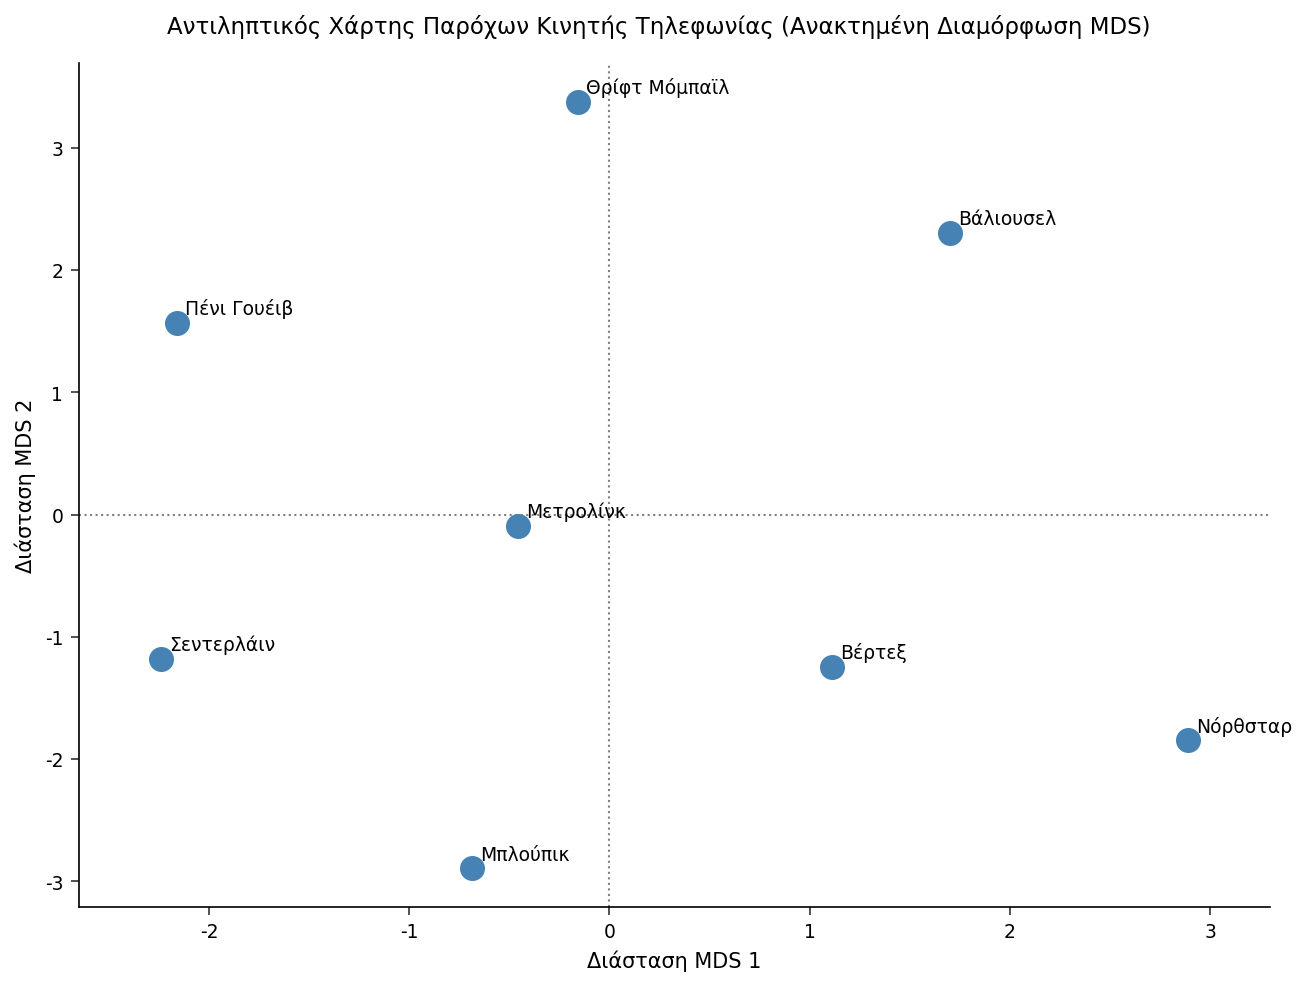

In [3]:
ΔΙΑΔΙΚΑΣΙΑ PRINT ΔΕΔΟΜΕΝΑ=mds_out ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ _name_='Πάροχος' DIM1='Διάσταση 1' DIM2='Διάσταση 2';
    TITLE 'Ανακτημένη Διαμόρφωση MDS (Συντεταγμένες Αντικειμένων)';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ PRINT ΔΕΔΟΜΕΝΑ=mds_fit ΕΤΙΚΕΤΑ;
    TITLE 'Σύνοψη Κακής Προσαρμογής MDS';
ΕΚΤΕΛΕΣΗ;

/* Διατηρούμε τις γραμμές διαμόρφωσης και δίνουμε στη μάρκα μια απλά
   ονομασμένη στήλη ετικέτας ώστε η SGPLOT να μπορεί να την τυπώσει
   δίπλα σε κάθε σημείο. */
ΔΕΔΟΜΕΝΑ mds_config;
    ΟΡΙΣΜΟΣ mds_out;
    ΟΠΟΥ _TYPE_ = 'CONFIG';
    LENGTH Brand $ 40;
    Brand = _NAME_;
    ΚΡΑΤΗΣΗ Brand DIM1 DIM2;
ΕΚΤΕΛΕΣΗ;

/* Σχεδιάζουμε τον αντιληπτικό χάρτη από τις ανακτημένες συντεταγμένες,
   επισημαίνοντας κάθε δείκτη με το όνομα του παρόχου. */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=mds_config;
    SCATTER x=DIM1 y=DIM2 / DATALABEL=Brand
            MARKERATTRS=(SYMBOL=circlefilled size=11 color=steelblue)
            datalabelattrs=(size=9);
    REFLINE 0 / AXIS=x LINEATTRS=(pattern=dot color=gray);
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=dot color=gray);
    XAXIS ΕΤΙΚΕΤΑ='Διάσταση MDS 1';
    YAXIS ΕΤΙΚΕΤΑ='Διάσταση MDS 2';
    TITLE 'Αντιληπτικός Χάρτης Παρόχων Κινητής Τηλεφωνίας (Ανακτημένη Διαμόρφωση MDS)';
ΕΚΤΕΛΕΣΗ;

## Βήμα 4 — Κατάταξη αντιληπτών υποκατάστατων

Ένα πρακτικό παραδοτέο για την ομάδα μάρκας είναι, για κάθε πάροχο, ο ανταγωνιστής που θεωρείται *πιο παρόμοιος* (η μικρότερη εκτός διαγωνίου ανομοιότητα). Αναδιαμορφώνουμε τον πίνακα σε μακριά μορφή και εξάγουμε τον πλησιέστερο γείτονα ανά πάροχο — αυτά τα ζεύγη είναι τα πλησιέστερα υποκατάστατα και οι πιο έντονες ανταγωνιστικές απειλές.

In [4]:
ΔΕΔΟΜΕΝΑ dissim_long;
    ΟΡΙΣΜΟΣ carrier_dissim;
    LENGTH Other $ 40;
    ARRAY d[8] D1-D8;
    ΕΠΑΝΑΛΗΨΗ j = 1 ΕΩΣ 8;
        ΕΑΝ      j=1 ΤΟΤΕ Other="Νόρθσταρ";
        ΑΛΛΙΩΣ ΕΑΝ j=2 ΤΟΤΕ Other="Μπλούπικ";
        ΑΛΛΙΩΣ ΕΑΝ j=3 ΤΟΤΕ Other="Βέρτεξ";
        ΑΛΛΙΩΣ ΕΑΝ j=4 ΤΟΤΕ Other="Μετρολίνκ";
        ΑΛΛΙΩΣ ΕΑΝ j=5 ΤΟΤΕ Other="Βάλιουσελ";
        ΑΛΛΙΩΣ ΕΑΝ j=6 ΤΟΤΕ Other="Θρίφτ Μόμπαϊλ";
        ΑΛΛΙΩΣ ΕΑΝ j=7 ΤΟΤΕ Other="Σεντερλάιν";
        ΑΛΛΙΩΣ ΕΑΝ j=8 ΤΟΤΕ Other="Πένι Γουέιβ";
        Dissimilarity = d[j];
        ΕΑΝ Carrier ne Other ΤΟΤΕ ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΚΡΑΤΗΣΗ Carrier Other Dissimilarity;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SORT ΔΕΔΟΜΕΝΑ=dissim_long;
    ΚΑΤΑ Carrier Dissimilarity;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ nearest;
    ΟΡΙΣΜΟΣ dissim_long;
    ΚΑΤΑ Carrier Dissimilarity;
    ΕΑΝ first.Carrier;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ PRINT ΔΕΔΟΜΕΝΑ=nearest noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ Carrier = 'Πάροχος'
          Other = 'Πλησιέστερος Αντιληπτός Ανταγωνιστής'
          Dissimilarity = 'Ανομοιότητα';
    TITLE 'Κάθε Πάροχος και ο Πλησιέστερος Αντιληπτός Ανταγωνιστής του';
ΕΚΤΕΛΕΣΗ;

                              Κάθε Πάροχος και ο Πλησιέστερος Αντιληπτός Ανταγωνιστής του                               

                  Πάροχος                                    Πλησιέστερος Αντιληπτός Ανταγωνιστής             Ανομοιότητα
Βάλιουσελ                  Θρίφτ Μόμπαϊλ                                                                              1.8
Βέρτεξ                     Νόρθσταρ                                                                                   1.6
Θρίφτ Μόμπαϊλ              Βάλιουσελ                                                                                  1.8
Μετρολίνκ                  Βέρτεξ                                                                                     1.7
Μπλούπικ                   Σεντερλάιν                                                                                   2
Νόρθσταρ                   Βέρτεξ                                                                                     1.6
Πένι Γουέιβ             


NOTE: DATA dissim_long


NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SORT data=dissim_long

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 56 rows from dissim_long.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA nearest


NOTE: Read 56 rows from dissim_long.
NOTE: Wrote nearest (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=nearest

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Ερμηνεία των αποτελεσμάτων

Επειδή δημιουργήσαμε τις ανομοιότητες από μια γνήσια δισδιάστατη λανθάνουσα δομή (ποιότητα δικτύου και τιμή/αξία, κατασκευασμένες ώστε να μεταβάλλονται ανεξάρτητα) συν μέτριο θόρυβο έρευνας, η `PROC MDS` ανακτά μια καθαρή δισδιάστατη διαμόρφωση. Το μέτρο κακής προσαρμογής σταθεροποιείται γύρω στο 1.85 - μια στενή προσαρμογή που επιβεβαιώνει ότι δύο διαστάσεις εξηγούν σχεδόν όλη την αντιληπτή δομή.

Διαβάζοντας τον ανακτημένο χάρτη (οι άξονες προσδιορίζονται μόνο μέχρι περιστροφής, ανάκλασης, και κλίμακας, οπότε ερμηνεύουμε κατευθύνσεις και όχι απόλυτα πρόσημα):

- **Ένας άξονας παρακολουθεί την ποιότητα δικτύου** - διαχωρίζει τις premium μάρκες εθνικής εμβέλειας (Νόρθσταρ, Βέρτεξ, Μπλούπικ) από τους φθηνούς εικονικούς παρόχους (Θρίφτ Μόμπαϊλ, Πένι Γουέιβ, Βάλιουσελ), με τους Μετρολίνκ και Σεντερλάιν να βρίσκονται στη μέση.
- **Ο άλλος άξονας παρακολουθεί την τιμή/αξία** - διαχωρίζει την επιθετική τοποθέτηση αξίας από την premium τοποθέτηση τιμής, γι' αυτό μια μάρκα υψηλής ποιότητας όπως η Μπλούπικ βρίσκεται μακριά από την εξίσου υψηλής ποιότητας Νόρθσταρ: μοιράζονται τη φήμη δικτύου αλλά ανταγωνίζονται σε πολύ διαφορετικές ιστορίες τιμής.
- Ο χάρτης δεν δείχνει καμία μοναδική κυρίαρχη κλίση: οι μάρκες απλώνονται και στα τέσσερα τεταρτημόρια, οπότε το ανταγωνιστικό τοπίο είναι γνησίως δισδιάστατο αντί για μία μόνο γραμμή premium-προς-οικονομικό.

Ο **πίνακας πλησιέστερου υποκατάστατου** μετατρέπει τον χάρτη σε λίστα δράσης. Ο πλησιέστερος αντιληπτός ανταγωνιστής κάθε παρόχου είναι η μάρκα που βρίσκεται δίπλα του στον χάρτη - οι Νόρθσταρ και Βέρτεξ αγκυροβολούν τη γωνία premium, οι Βάλιουσελ και Θρίφτ Μόμπαϊλ σχηματίζουν ζεύγος στη γωνία αξίας, και ο Μετρολίνκ διαβάζεται ως το πλησιέστερο υποκατάστατο για αρκετές μάρκες μεσαίας αγοράς επειδή καταλαμβάνει το κέντρο του χάρτη. Τα στενά ζεύγη επισημαίνουν άμεσους ανταγωνιστές· οι κενές περιοχές μεταξύ συστάδων αναδεικνύουν μη κατειλημμένη τοποθέτηση που θα μπορούσε να στοχεύσει μια προκλητική μάρκα.